In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
df = pd.read_csv(
    "data/Unemployment_Rate_upto_11_2020.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [ ]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())

(267, 9)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                               

In [ ]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Check column names
print(df.columns)

# Remove missing values
df = df.dropna()

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


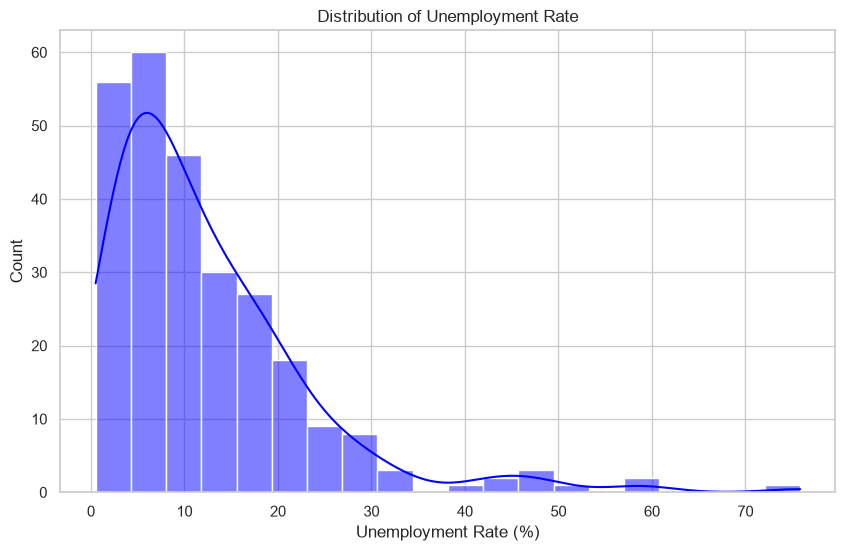

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True,
    color="blue"
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.show()

/var/folders/t0/6r4115c52934wxklzylr1hk00000gn/T/ipykernel_6230/4016288910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


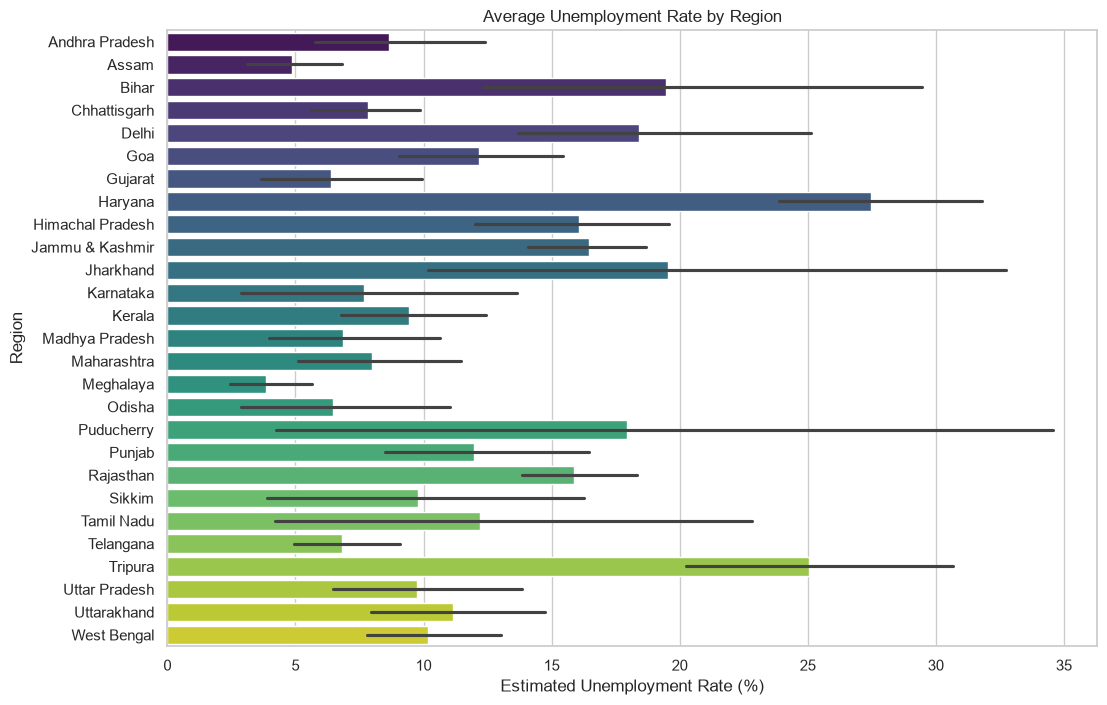

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    x="Estimated Unemployment Rate (%)",
    y="Region",
    data=df,
    palette="viridis"
)

plt.title("Average Unemployment Rate by Region")
plt.show()

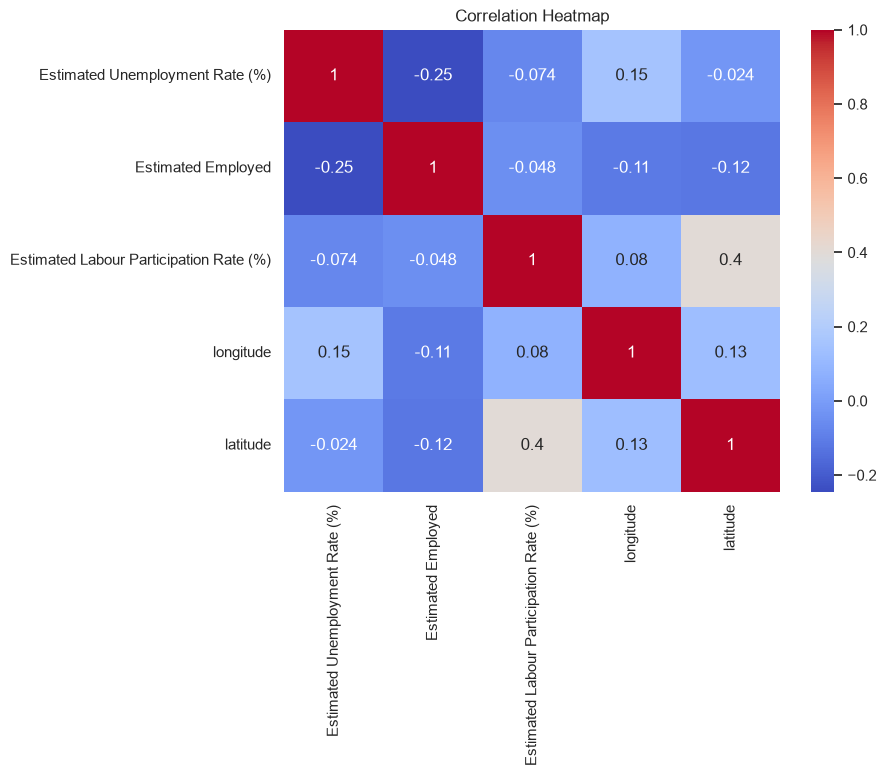

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

/var/folders/t0/6r4115c52934wxklzylr1hk00000gn/T/ipykernel_6230/2362350632.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


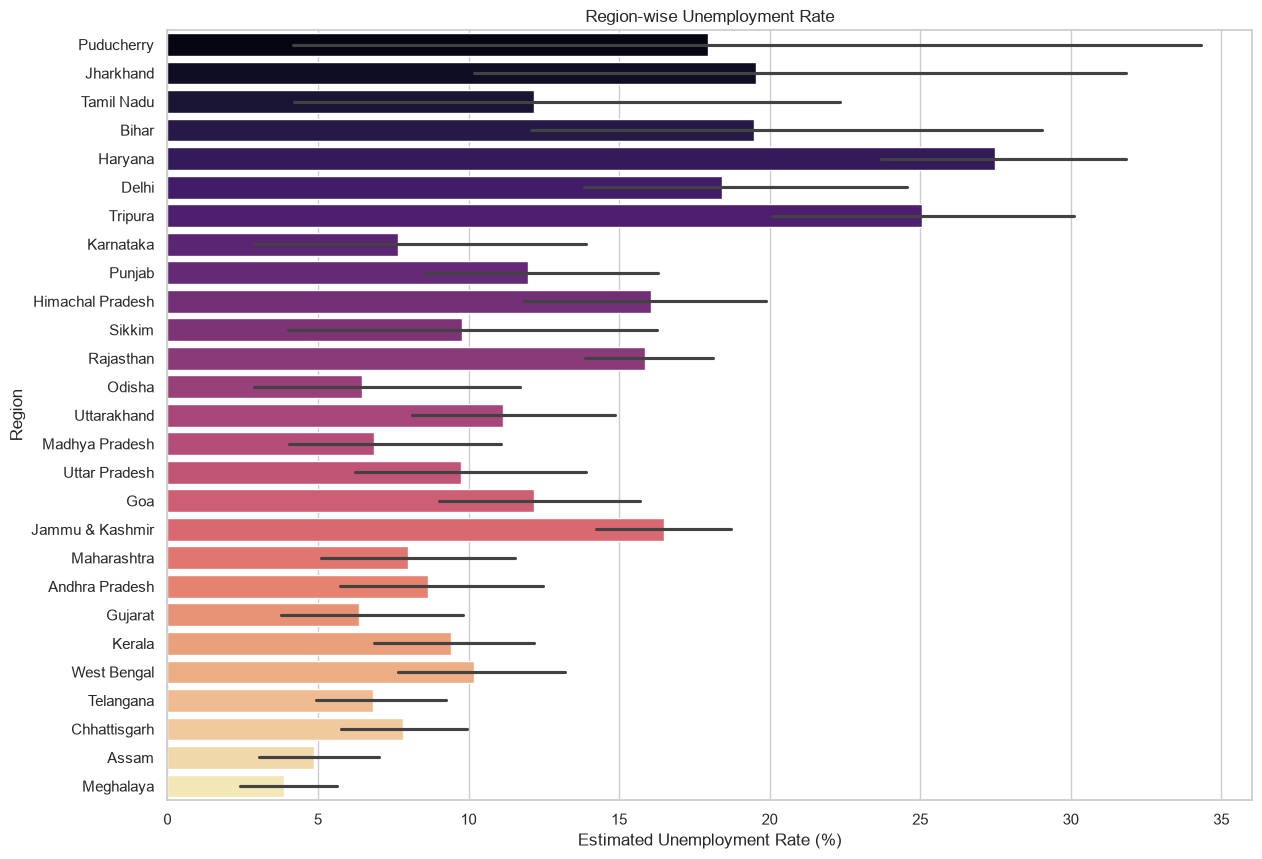

In [ ]:
plt.figure(figsize=(14,10))

sns.barplot(
    x="Estimated Unemployment Rate (%)",
    y="Region",
    data=df.sort_values(
        by="Estimated Unemployment Rate (%)",
        ascending=False
    ),
    palette="magma"
)

plt.title("Region-wise Unemployment Rate")
plt.show()

/var/folders/t0/6r4115c52934wxklzylr1hk00000gn/T/ipykernel_6230/2494790966.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


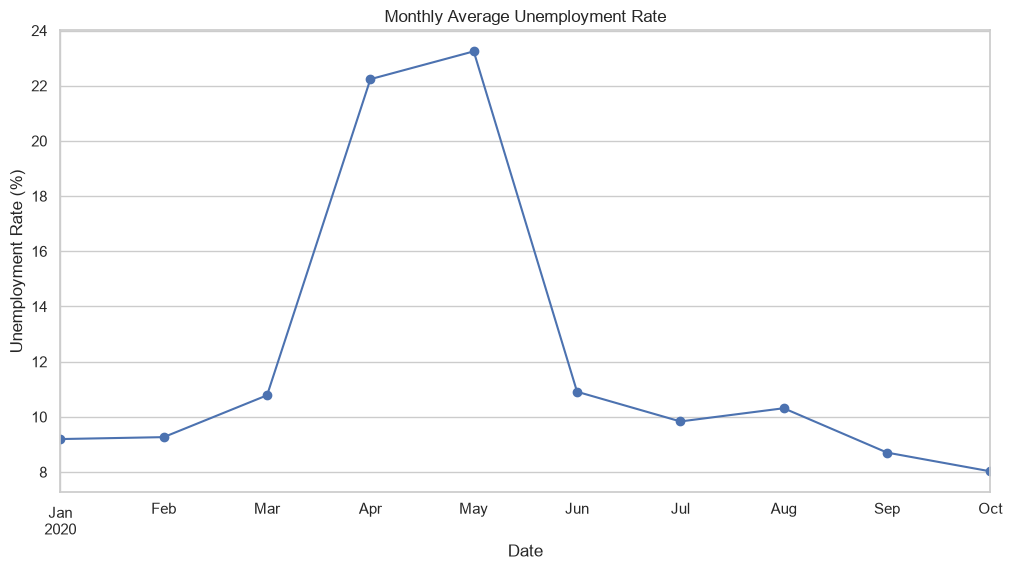

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

monthly = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,6))

monthly.plot(marker="o")

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)
plt.show()

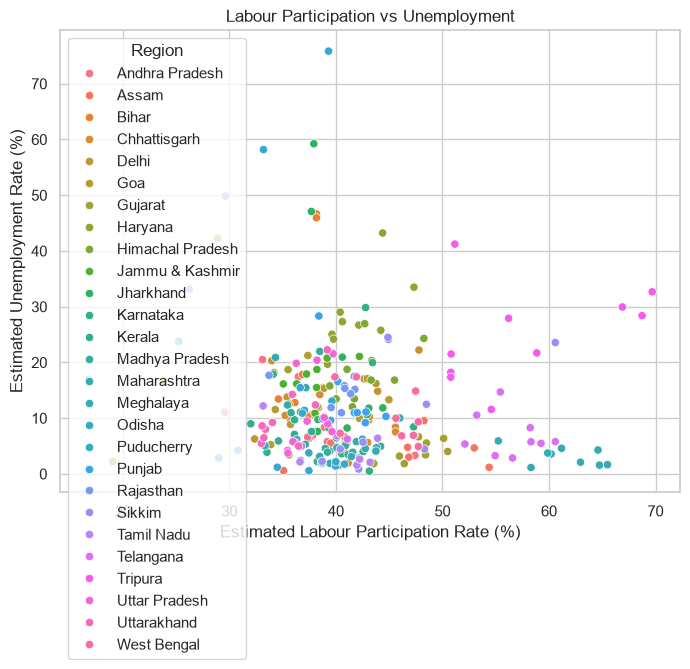

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    data=df
)

plt.title("Labour Participation vs Unemployment")
plt.show()

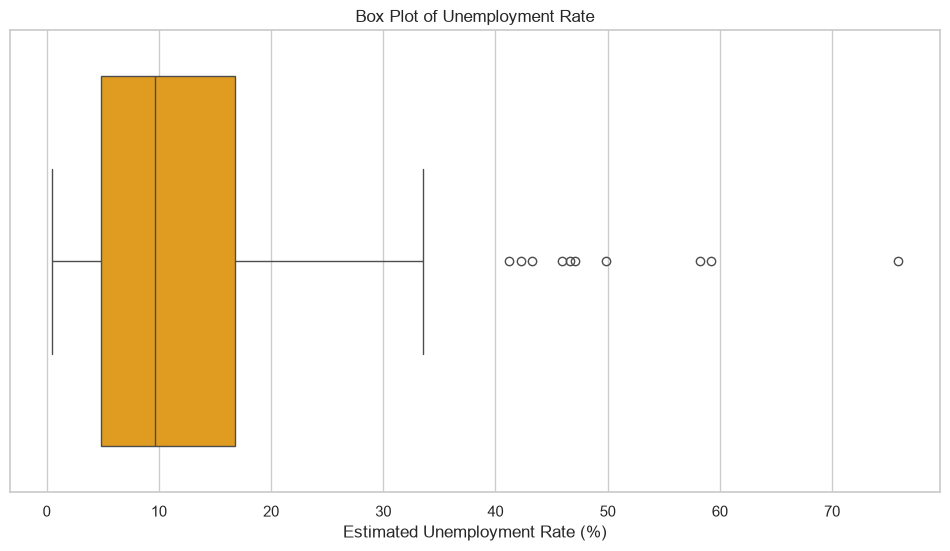

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Estimated Unemployment Rate (%)",
    data=df,
    color="orange"
)

plt.title("Box Plot of Unemployment Rate")
plt.show()

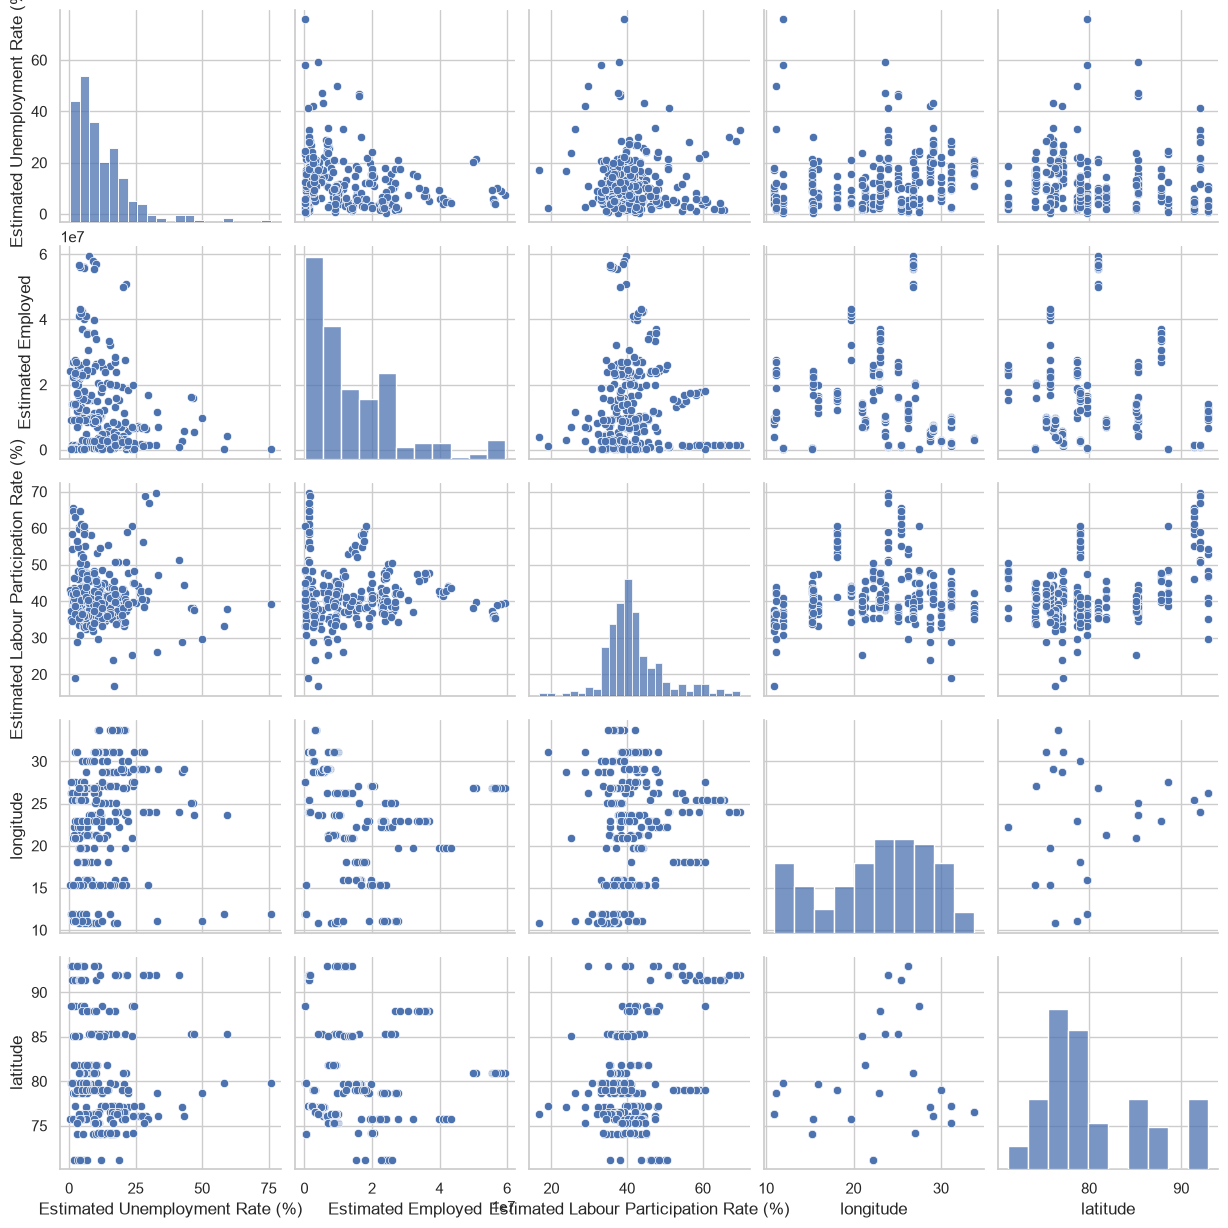

In [ ]:
sns.pairplot(
    df.select_dtypes(include="number")
)

plt.show()